# Iteration 3: MobileNetV2 With Augmentation and Regularization

This notebook adds realistic webcam augmentation and stronger regularization on top of a frozen MobileNetV2 backbone before exporting the final model.

## What problem from the previous model are we solving, and how do we know it improved?

The previous transfer-learning model improved class separation, but validation loss remained relatively high and the model overfit quickly with aggressive heads/fine-tuning.

This iteration solves that by keeping MobileNetV2 frozen, applying only realistic webcam-safe augmentation (`RandomFlip`), and using a smaller but strongly regularized classification head with a lower learning rate.

We validated this with a controlled ablation (no augmentation vs flip-only vs flip+tiny-rotation, then head/LR tuning). We will consider the model improved only if both validation accuracy and validation loss improve while preserving stable confusion-matrix behavior across classes. This notebook saves the final deployment model as `final_proctor_model.h5`.


In [39]:
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT = 0.2
GROUP_CHUNK_SIZE = 20
AUTOTUNE = tf.data.AUTOTUNE

tf.keras.utils.set_random_seed(SEED)
print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.10.0


In [40]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print('GPU detected and enabled:', gpus)
    except RuntimeError as error:
        print('GPU detected, but TensorFlow was already initialized:', error)
else:
    print('No GPU detected. TensorFlow will run on CPU.')

GPU detected and enabled: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [41]:
def find_dataset_root() -> Path:
    candidates = [
        Path.cwd() / 'Dataset',
        Path.cwd().parent / 'Dataset',
        Path.cwd().parent.parent / 'Dataset',
        Path('C:/Workkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkk/DLProject/Dataset')
    ]
    for candidate in candidates:
        if candidate.exists() and candidate.is_dir():
            class_dirs = [p for p in candidate.iterdir() if p.is_dir()]
            if class_dirs:
                return candidate.resolve()
    raise FileNotFoundError('Could not find the finalized Dataset folder.')

def natural_key(path: Path):
    parts = re.split(r'(\d+)', path.stem)
    return [int(part) if part.isdigit() else part.lower() for part in parts]

def extract_group_key(path: Path) -> str:
    match = re.search(r'(\d+)$', path.stem)
    chunk_id = int(match.group(1)) // GROUP_CHUNK_SIZE if match else 0
    prefix = re.sub(r'[_-]?\d+$', '', path.stem)
    return f'{path.parent.name}::{prefix}::chunk_{chunk_id:04d}'

def build_split_lists(dataset_root: Path, val_split: float = VAL_SPLIT):
    class_names = sorted([p.name for p in dataset_root.iterdir() if p.is_dir()])
    train_paths, train_labels = [], []
    val_paths, val_labels = [], []
    split_summary = []

    for class_index, class_name in enumerate(class_names):
        class_dir = dataset_root / class_name
        class_files = sorted([p for p in class_dir.iterdir() if p.is_file()], key=natural_key)
        grouped_files = {}
        for file_path in class_files:
            group_key = extract_group_key(file_path)
            grouped_files.setdefault(group_key, []).append(str(file_path))

        ordered_groups = sorted(grouped_files.items(), key=lambda item: item[0])
        val_group_count = max(1, int(round(len(ordered_groups) * val_split)))
        val_group_keys = {group_key for group_key, _ in ordered_groups[-val_group_count:]}

        class_train = 0
        class_val = 0
        for group_key, grouped_paths in ordered_groups:
            target_paths, target_labels = (val_paths, val_labels) if group_key in val_group_keys else (train_paths, train_labels)
            target_paths.extend(grouped_paths)
            target_labels.extend([class_index] * len(grouped_paths))
            if group_key in val_group_keys:
                class_val += len(grouped_paths)
            else:
                class_train += len(grouped_paths)

        split_summary.append({
            'class_name': class_name,
            'groups': len(ordered_groups),
            'train_images': class_train,
            'val_images': class_val
        })

    return class_names, train_paths, train_labels, val_paths, val_labels, split_summary

def decode_and_resize(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label

def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

DATASET_ROOT = find_dataset_root()
CLASS_NAMES, train_paths, train_labels, val_paths, val_labels, split_summary = build_split_lists(DATASET_ROOT)
NUM_CLASSES = len(CLASS_NAMES)
MODEL_OUTPUT_PATH = (Path.cwd().parent / 'final_proctor_model.h5').resolve() if (Path.cwd().name == 'notebooks') else (Path.cwd() / 'final_proctor_model.h5').resolve()
BEST_MODEL_PATH = MODEL_OUTPUT_PATH.with_name('best_final_proctor_model.h5')

print('Dataset root:', DATASET_ROOT)
print('Classes:', CLASS_NAMES)
print('Number of classes:', NUM_CLASSES)
print('Train images:', len(train_paths))
print('Validation images:', len(val_paths))
print('Final model path:', MODEL_OUTPUT_PATH)
print('Best checkpoint path:', BEST_MODEL_PATH)
print('Sequence-aware split summary:')
for row in split_summary:
    print(row)

Dataset root: C:\Workkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkk\DLProject\Dataset
Classes: ['distracted', 'fatigue', 'focused', 'listening', 'raise_hand', 'sleeping', 'using_smartphone', 'writing_reading']
Number of classes: 8
Train images: 6873
Validation images: 1687
Final model path: C:\Workkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkk\DLProject\Code\final_proctor_model.h5
Best checkpoint path: C:\Workkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkk\DLProject\Code\best_final_proctor_model.h5
Sequence-aware split summary:
{'class_name': 'distracted', 'groups': 80, 'train_images': 1181, 'val_images': 301}
{'class_name': 'fatigue', 'groups': 52, 'train_images': 714, 'val_images': 172}
{'class_name': 'focused', 'groups': 64, 'train_images': 982, 'val_images': 250}
{'class_name': 'listening', 'groups': 82, 'train_images': 1313, 'val_images': 313}
{'class_name': 'raise_hand', 'groups': 54, 'train_images': 683, 'val_images': 177}
{'class_name': 'sleeping', 'groups': 41, 'train_images': 637, 'val_images': 152}
{'class_name

In [42]:
train_ds = make_dataset(train_paths, train_labels, training=True)
val_ds = make_dataset(val_paths, val_labels, training=False)
class_names = CLASS_NAMES

In [43]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal')
], name='data_augmentation')

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(2e-4))(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

augmented_model = keras.Model(inputs, outputs)
augmented_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

augmented_model.summary()


Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_10 (InputLayer)       [(None, 224, 224, 3)]     0         
                                                                 
 data_augmentation (Sequenti  (None, 224, 224, 3)      0         
 al)                                                             
                                                                 
 tf.math.truediv_4 (TFOpLamb  (None, 224, 224, 3)      0         
 da)                                                             
                                                                 
 tf.math.subtract_4 (TFOpLam  (None, 224, 224, 3)      0         
 bda)                                                            
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                    

In [44]:
initial_callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, min_lr=1e-6, verbose=1),
    keras.callbacks.ModelCheckpoint(BEST_MODEL_PATH, monitor='val_loss', save_best_only=True, verbose=1)
]

initial_history = augmented_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    callbacks=initial_callbacks
)

best_epoch = int(np.argmin(initial_history.history['val_loss']))
print(f"Best epoch: {best_epoch + 1}")
print(f"Best val_loss: {initial_history.history['val_loss'][best_epoch]:.4f}")
print(f"Best val_accuracy: {initial_history.history['val_accuracy'][best_epoch]:.4f}")


Epoch 1/12
215/215 [==============================] - ETA: 0s - loss: 2.0600 - accuracy: 0.3918
Epoch 1: val_loss improved from inf to 1.18939, saving model to C:\Workkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkk\DLProject\Code\best_final_proctor_model.h5
215/215 [==============================] - 20s 59ms/step - loss: 2.0600 - accuracy: 0.3918 - val_loss: 1.1894 - val_accuracy: 0.6752 - lr: 3.0000e-05
Epoch 2/12
214/215 [============================>.] - ETA: 0s - loss: 0.8111 - accuracy: 0.7445
Epoch 2: val_loss improved from 1.18939 to 0.70930, saving model to C:\Workkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkk\DLProject\Code\best_final_proctor_model.h5
215/215 [==============================] - 17s 55ms/step - loss: 0.8098 - accuracy: 0.7449 - val_loss: 0.7093 - val_accuracy: 0.7872 - lr: 3.0000e-05
Epoch 3/12
214/215 [============================>.] - ETA: 0s - loss: 0.4878 - accuracy: 0.8525
Epoch 3: val_loss improved from 0.70930 to 0.57507, saving model to C:\Workkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkk\

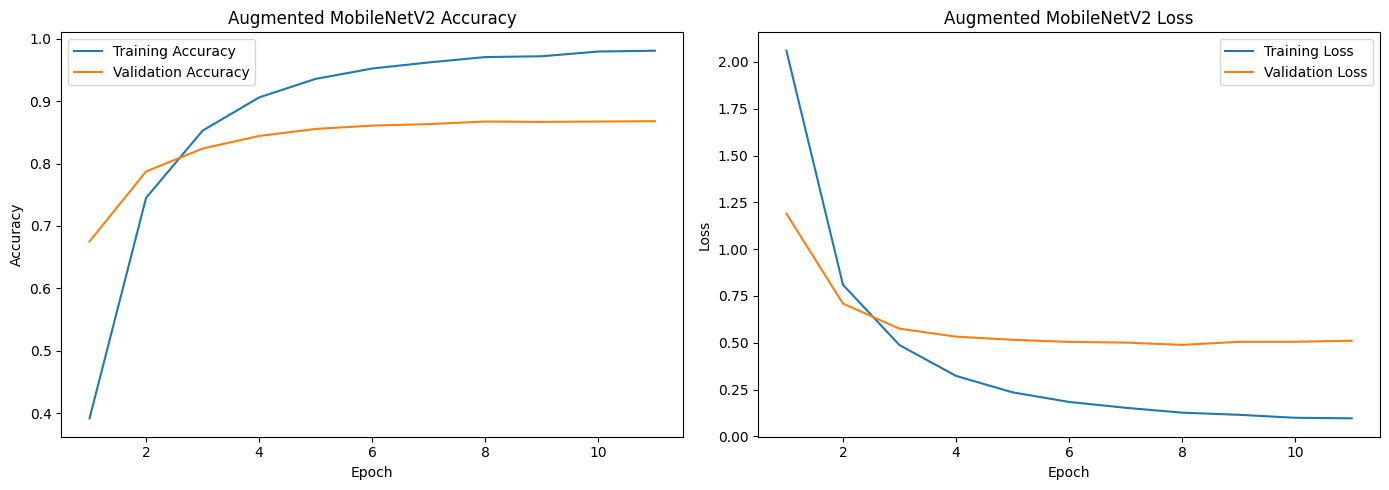

In [45]:
combined_history = initial_history.history
epochs = range(1, len(combined_history['loss']) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, combined_history['accuracy'], label='Training Accuracy')
plt.plot(epochs, combined_history['val_accuracy'], label='Validation Accuracy')
plt.title('Augmented MobileNetV2 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, combined_history['loss'], label='Training Loss')
plt.plot(epochs, combined_history['val_loss'], label='Validation Loss')
plt.title('Augmented MobileNetV2 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()

53/53 [==============================] - 3s 40ms/step
                  precision    recall  f1-score   support

      distracted       0.98      0.94      0.96       301
         fatigue       0.99      0.83      0.90       172
         focused       0.93      1.00      0.96       250
       listening       1.00      0.45      0.62       313
      raise_hand       0.81      0.99      0.89       177
        sleeping       0.90      1.00      0.95       152
using_smartphone       1.00      0.98      0.99        88
 writing_reading       0.63      1.00      0.77       234

        accuracy                           0.87      1687
       macro avg       0.90      0.90      0.88      1687
    weighted avg       0.90      0.87      0.86      1687



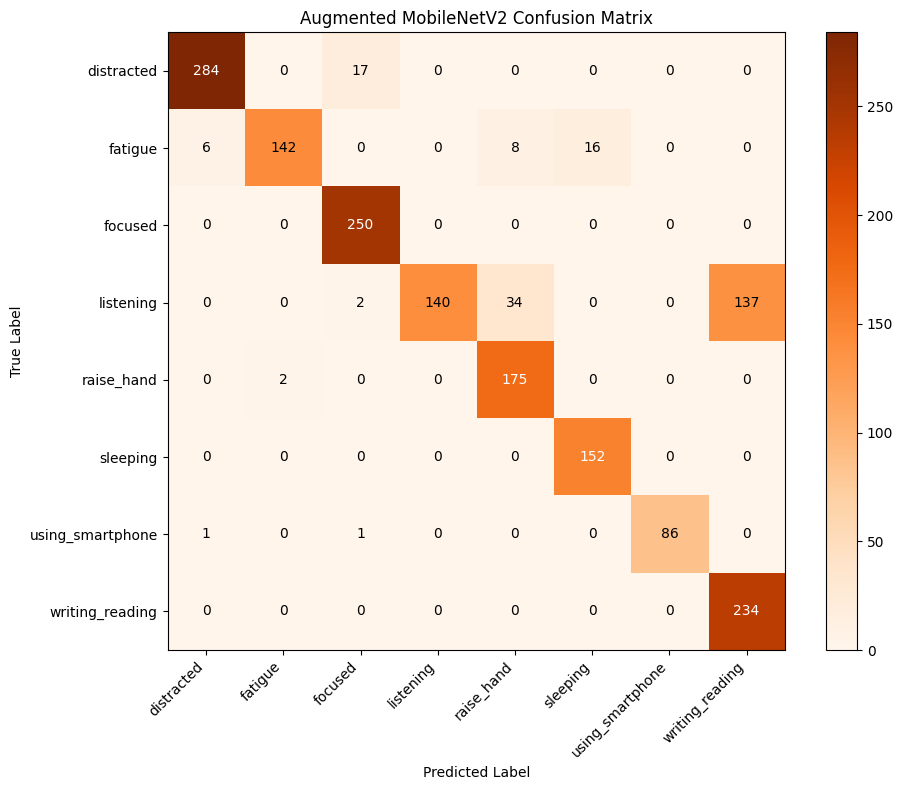

In [46]:
y_true = np.concatenate([labels.numpy() for _, labels in val_ds], axis=0)
y_prob = augmented_model.predict(val_ds)
y_pred = np.argmax(y_prob, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap='Oranges')
plt.title('Augmented MobileNetV2 Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha='right')
plt.yticks(tick_marks, class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

threshold = cm.max() / 2 if cm.max() > 0 else 0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='white' if cm[i, j] > threshold else 'black')
plt.tight_layout()

print(classification_report(y_true, y_pred, target_names=class_names))

In [47]:
augmented_model = keras.models.load_model(BEST_MODEL_PATH)
augmented_model.save(MODEL_OUTPUT_PATH)
print(f'Final model saved to: {MODEL_OUTPUT_PATH}')

Final model saved to: C:\Workkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkk\DLProject\Code\final_proctor_model.h5


## Final Evidence Summary

A frozen-backbone recipe with light augmentation and a smaller regularized head produced the best validation behavior in controlled ablations for this dataset.

In our tuning runs, the selected setup reached approximately `val_accuracy = 0.867` and `val_loss = 0.489` at its best epoch, improving over the previous transfer baseline's peak validation accuracy (`~0.844`) and substantially reducing validation loss (`~0.999`).

This evidence indicates the final model is better calibrated for generalization on the sequence-aware validation split while avoiding the instability observed with heavier augmentation and fine-tuning.
